# Preparación y Procesamiento de Datos — Spider Dataset
## Análisis Comparativo de Técnicas de IA para Text-to-SQL con Visualización Automática
### Maestría en Inteligencia Artificial — UEES
**Grupo Sánchez-Cabrera** | Abril 2025

---

Este notebook implementa la fase completa de **preparación de datos** usando el dataset Spider (Yale, 2018),
benchmark estándar para la tarea Text-to-SQL. Se cubren los siguientes elementos:

1. Carga completa del dataset desde Hugging Face
2. Análisis Exploratorio de Datos (EDA)
3. Pipeline de limpieza de datos
4. Feature Engineering avanzado
5. Estrategias de balanceamiento de datos
6. Técnicas de Data Augmentation para Text-to-SQL
7. Pipeline de preprocesamiento automatizado

**Referencia:** Yu, T. et al. (2018). Spider: A Large-Scale Human-Labeled Dataset for Complex and Cross-Domain
Semantic Parsing and Text-to-SQL Task. EMNLP 2018.

## 0. Instalación de Dependencias

Se instalan todas las librerías necesarias para el pipeline completo.
Ejecutar esta celda una sola vez por entorno.

In [1]:
# ─── Instalación de dependencias ───────────────────────────────────────────────
# datasets: acceso a Hugging Face Hub
# pandas / numpy: manipulación de datos
# matplotlib / seaborn / plotly: visualización
# nltk / spacy: procesamiento de lenguaje natural
# imbalanced-learn: balanceamiento de clases
# scikit-learn: ML utilities
# sqlparse: análisis sintáctico de SQL
# wordcloud: visualización de frecuencias

!pip install -q datasets pandas numpy matplotlib seaborn plotly \
                 nltk spacy imbalanced-learn scikit-learn \
                 sqlparse wordcloud tqdm transformers

# Descargar modelo de spaCy en inglés (requerido para tokenización avanzada)
!python -m spacy download en_core_web_sm -q

print("✅ Dependencias instaladas correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 20.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 150.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Dependencias instaladas correctamente.


## 1. Carga Completa del Dataset Spider desde Hugging Face

Spider se carga directamente desde el Hub de Hugging Face en su versión completa.
El dataset está dividido en dos splits:
- **train**: 7,000 ejemplos para entrenamiento
- **validation**: 1,034 ejemplos para evaluación

Cada ejemplo contiene: pregunta en lenguaje natural, consulta SQL objetivo,
identificador de base de datos y nivel de dificultad.

In [2]:
# ─── Importaciones principales ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import re
import json
import os
from collections import Counter
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Librerías importadas.")

✅ Librerías importadas.


In [3]:
# ─── Carga del dataset completo desde Hugging Face ────────────────────────────
# Se usa la librería `datasets` de HF que descarga y cachea automáticamente.
# trust_remote_code=True es necesario para datasets con scripts de carga propios.

from datasets import load_dataset, DatasetDict

print("⏳ Descargando Spider desde Hugging Face Hub...")
raw_dataset = load_dataset("xlangai/spider", trust_remote_code=True)

print(f"\n📊 Estructura del dataset:")
print(raw_dataset)

# Convertir a DataFrames para facilitar el análisis
df_train = raw_dataset["train"].to_pandas()
df_val   = raw_dataset["validation"].to_pandas()

# Dataset unificado para análisis exploratorio global
df_all = pd.concat([df_train, df_val], ignore_index=True)
df_all['split'] = ['train'] * len(df_train) + ['validation'] * len(df_val)

print(f"\n✅ Dataset cargado exitosamente:")
print(f"   Train      : {len(df_train):,} ejemplos")
print(f"   Validation : {len(df_val):,} ejemplos")
print(f"   Total      : {len(df_all):,} ejemplos")
print(f"\nColumnas disponibles: {list(df_all.columns)}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'xlangai/spider' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'xlangai/spider' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


⏳ Descargando Spider desde Hugging Face Hub...


README.md: 0.00B [00:00, ?B/s]

spider/train-00000-of-00001.parquet:   0%|          | 0.00/831k [00:00<?, ?B/s]

spider/validation-00000-of-00001.parquet:   0%|          | 0.00/126k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1034 [00:00<?, ? examples/s]


📊 Estructura del dataset:
DatasetDict({
    train: Dataset({
        features: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks'],
        num_rows: 7000
    })
    validation: Dataset({
        features: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks'],
        num_rows: 1034
    })
})

✅ Dataset cargado exitosamente:
   Train      : 7,000 ejemplos
   Validation : 1,034 ejemplos
   Total      : 8,034 ejemplos

Columnas disponibles: ['db_id', 'query', 'question', 'query_toks', 'query_toks_no_value', 'question_toks', 'split']


In [4]:
# ─── Inspección inicial del dataset ───────────────────────────────────────────
# Visualizar los primeros registros para entender la estructura real de los datos

print("=" * 80)
print("MUESTRA DE DATOS — PRIMEROS 3 REGISTROS")
print("=" * 80)

for i, row in df_train.head(3).iterrows():
    print(f"\n[Ejemplo {i+1}]")
    print(f"  DB         : {row.get('db_id', 'N/A')}")
    print(f"  Pregunta   : {row.get('question', 'N/A')}")
    print(f"  SQL        : {row.get('query', 'N/A')}")
    print(f"  Dificultad : {row.get('query_toks', 'N/A') if 'difficulty' not in row else row['difficulty']}")
    print("-" * 60)

print("\n📋 Tipos de datos:")
print(df_all.dtypes)

print("\n📋 Valores nulos por columna:")
print(df_all.isnull().sum())

MUESTRA DE DATOS — PRIMEROS 3 REGISTROS

[Ejemplo 1]
  DB         : department_management
  Pregunta   : How many heads of the departments are older than 56 ?
  SQL        : SELECT count(*) FROM head WHERE age  >  56
  Dificultad : ['SELECT' 'count' '(' '*' ')' 'FROM' 'head' 'WHERE' 'age' '>' '56']
------------------------------------------------------------

[Ejemplo 2]
  DB         : department_management
  Pregunta   : List the name, born state and age of the heads of departments ordered by age.
  SQL        : SELECT name ,  born_state ,  age FROM head ORDER BY age
  Dificultad : ['SELECT' 'name' ',' 'born_state' ',' 'age' 'FROM' 'head' 'ORDER' 'BY'
 'age']
------------------------------------------------------------

[Ejemplo 3]
  DB         : department_management
  Pregunta   : List the creation year, name and budget of each department.
  SQL        : SELECT creation ,  name ,  budget_in_billions FROM department
  Dificultad : ['SELECT' 'creation' ',' 'name' ',' 'budget_in_billio

---
## 2. Análisis Exploratorio de Datos (EDA)

El EDA es la fase de diagnóstico del dataset. Aquí identificamos:
- Distribución de la variable objetivo (dificultad de las consultas SQL)
- Características estadísticas de las preguntas en lenguaje natural
- Patrones en la estructura SQL (cláusulas más frecuentes)
- Diversidad de dominios de bases de datos
- Calidad de los datos (valores nulos, duplicados, anomalías)

Este análisis guía todas las decisiones posteriores de preprocesamiento.

In [5]:
# ─── 2.1 Ingeniería básica de features para el EDA ────────────────────────────
# Calculamos métricas derivadas que nos permiten analizar el dataset en profundidad.
# Estas features también serán parte del Feature Engineering final.

import sqlparse
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

def extract_sql_features(sql):
    """Extrae características estructurales de una consulta SQL."""
    sql_upper = sql.upper()
    return {
        'has_join'       : int('JOIN' in sql_upper),
        'has_subquery'   : int('SELECT' in sql_upper[sql_upper.find('FROM'):] if 'FROM' in sql_upper else False),
        'has_group_by'   : int('GROUP BY' in sql_upper),
        'has_order_by'   : int('ORDER BY' in sql_upper),
        'has_having'     : int('HAVING' in sql_upper),
        'has_where'      : int('WHERE' in sql_upper),
        'has_distinct'   : int('DISTINCT' in sql_upper),
        'has_limit'      : int('LIMIT' in sql_upper),
        'has_union'      : int('UNION' in sql_upper),
        'has_intersect'  : int('INTERSECT' in sql_upper),
        'has_except'     : int('EXCEPT' in sql_upper),
        'has_count'      : int('COUNT(' in sql_upper),
        'has_avg'        : int('AVG(' in sql_upper),
        'has_sum'        : int('SUM(' in sql_upper),
        'has_max_min'    : int('MAX(' in sql_upper or 'MIN(' in sql_upper),
        'join_count'     : sql_upper.count('JOIN'),
        'sql_length'     : len(sql),
        'sql_token_count': len(sql.split()),
        'clause_count'   : sum([1 for kw in ['SELECT','FROM','WHERE','GROUP BY','ORDER BY','HAVING','LIMIT']
                                if kw in sql_upper]),
    }

# Aplicar extracción de features SQL al dataset completo
tqdm.pandas(desc="Extrayendo features SQL")
sql_features = df_all['query'].progress_apply(extract_sql_features)
df_sql = pd.DataFrame(sql_features.tolist())

# Features de la pregunta en lenguaje natural
df_all['question_length']     = df_all['question'].apply(len)
df_all['question_word_count'] = df_all['question'].apply(lambda x: len(x.split()))
df_all['question_char_count'] = df_all['question'].apply(len)

# Incorporar features SQL al dataframe principal
df_all = pd.concat([df_all.reset_index(drop=True), df_sql], axis=1)

# Calcular score de complejidad SQL compuesto (métrica propia)
complexity_weights = {
    'has_join': 2, 'has_subquery': 3, 'has_group_by': 1.5,
    'has_having': 2, 'has_union': 2.5, 'has_intersect': 2.5,
    'has_except': 2.5, 'has_distinct': 1, 'join_count': 1
}
df_all['complexity_score'] = sum(
    df_all[col] * w for col, w in complexity_weights.items()
)

print("✅ Features básicas calculadas para todo el dataset.")
print(f"   Features totales disponibles: {len(df_all.columns)}")

Extrayendo features SQL:   0%|          | 0/8034 [00:00<?, ?it/s]

✅ Features básicas calculadas para todo el dataset.
   Features totales disponibles: 30


In [6]:
# ─── 2.2 Estadísticas descriptivas globales ────────────────────────────────────
# Resumen estadístico de las variables clave del dataset

print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS — SPIDER DATASET COMPLETO")
print("=" * 70)

stats_cols = ['question_word_count', 'sql_token_count', 'sql_length',
              'clause_count', 'join_count', 'complexity_score']

desc = df_all[stats_cols].describe().round(2)
desc.index = ['N', 'Media', 'Desv. Est.', 'Mín', 'Q25', 'Mediana', 'Q75', 'Máx']
print(desc.to_string())

print(f"\n📌 Hallazgos clave:")
print(f"   Longitud promedio pregunta : {df_all['question_word_count'].mean():.1f} palabras")
print(f"   Longitud promedio SQL      : {df_all['sql_token_count'].mean():.1f} tokens")
print(f"   Consultas con JOIN         : {df_all['has_join'].sum():,} ({df_all['has_join'].mean()*100:.1f}%)")
print(f"   Consultas con subconsulta  : {df_all['has_subquery'].sum():,} ({df_all['has_subquery'].mean()*100:.1f}%)")
print(f"   Consultas con GROUP BY     : {df_all['has_group_by'].sum():,} ({df_all['has_group_by'].mean()*100:.1f}%)")
print(f"   Bases de datos únicas      : {df_all['db_id'].nunique()}")
print(f"   Consultas únicas (query)   : {df_all['query'].nunique():,}")
print(f"   Duplicados exactos         : {df_all.duplicated(subset=['question','query']).sum()}")

ESTADÍSTICAS DESCRIPTIVAS — SPIDER DATASET COMPLETO
            question_word_count  sql_token_count  sql_length  clause_count  join_count  complexity_score
N                       8034.00          8034.00     8034.00       8034.00     8034.00           8034.00
Media                     12.69            15.85      109.26          3.21        0.54              2.57
Desv. Est.                 4.33             9.37       64.33          0.89        0.78              2.61
Mín                        3.00             4.00       18.00          2.00        0.00              0.00
Q25                       10.00             9.00       62.00          3.00        0.00              0.00
Mediana                   12.00            13.00       92.00          3.00        0.00              3.00
Q75                       15.00            21.00      146.00          4.00        1.00              4.00
Máx                       39.00            87.00      577.00          6.00        8.00             15.50

📌 

In [7]:
# ─── 2.3 Análisis de dificultad — variable objetivo ───────────────────────────
# La dificultad es la variable objetivo (label) para el análisis comparativo.
# Spider define 4 niveles: easy, medium, hard, extra hard.
# NOTA: Spider en HF no siempre incluye 'difficulty' como columna explícita;
# la inferimos del contenido SQL si no está disponible.

def infer_difficulty(row):
    """
    Infiere la dificultad de una consulta SQL basada en sus características.
    Lógica basada en las reglas de anotación originales de Spider (Yu et al., 2018).
    """
    sql = row['query'].upper()
    joins    = sql.count('JOIN')
    subq     = sql.count('SELECT') - 1  # subconsultas = SELECTs adicionales
    has_gb   = 'GROUP BY' in sql
    has_hav  = 'HAVING' in sql
    has_set  = any(op in sql for op in ['UNION', 'INTERSECT', 'EXCEPT'])
    has_nest = subq > 0

    if has_set or (has_nest and has_hav) or (joins >= 2 and has_nest):
        return 'extra'
    elif has_nest or (joins >= 2 and has_gb) or has_hav:
        return 'hard'
    elif joins >= 1 or has_gb or 'ORDER BY' in sql:
        return 'medium'
    else:
        return 'easy'

# Usar columna de dificultad si existe, sino inferirla
if 'difficulty' not in df_all.columns:
    tqdm.pandas(desc="Infiriendo dificultad")
    df_all['difficulty'] = df_all.progress_apply(infer_difficulty, axis=1)
    print("ℹ️  Columna 'difficulty' inferida desde estructura SQL.")
else:
    print("✅ Columna 'difficulty' disponible directamente en el dataset.")

# También calcularla para train y val por separado
df_train['difficulty'] = df_train.apply(infer_difficulty, axis=1)
df_val['difficulty']   = df_val.apply(infer_difficulty, axis=1)

# Distribución de dificultad
diff_order = ['easy', 'medium', 'hard', 'extra']
diff_counts = df_all['difficulty'].value_counts().reindex(diff_order)
diff_pct    = (diff_counts / len(df_all) * 100).round(1)

print("\n📊 Distribución de dificultad (dataset completo):")
for level, cnt, pct in zip(diff_order, diff_counts, diff_pct):
    bar = '█' * int(pct // 2)
    print(f"   {level:8s}: {cnt:5,} ({pct:5.1f}%) {bar}")

Infiriendo dificultad:   0%|          | 0/8034 [00:00<?, ?it/s]

ℹ️  Columna 'difficulty' inferida desde estructura SQL.

📊 Distribución de dificultad (dataset completo):
   easy    : 2,380 ( 29.6%) ██████████████
   medium  : 3,940 ( 49.0%) ████████████████████████
   hard    : 1,049 ( 13.1%) ██████
   extra   :   665 (  8.3%) ████


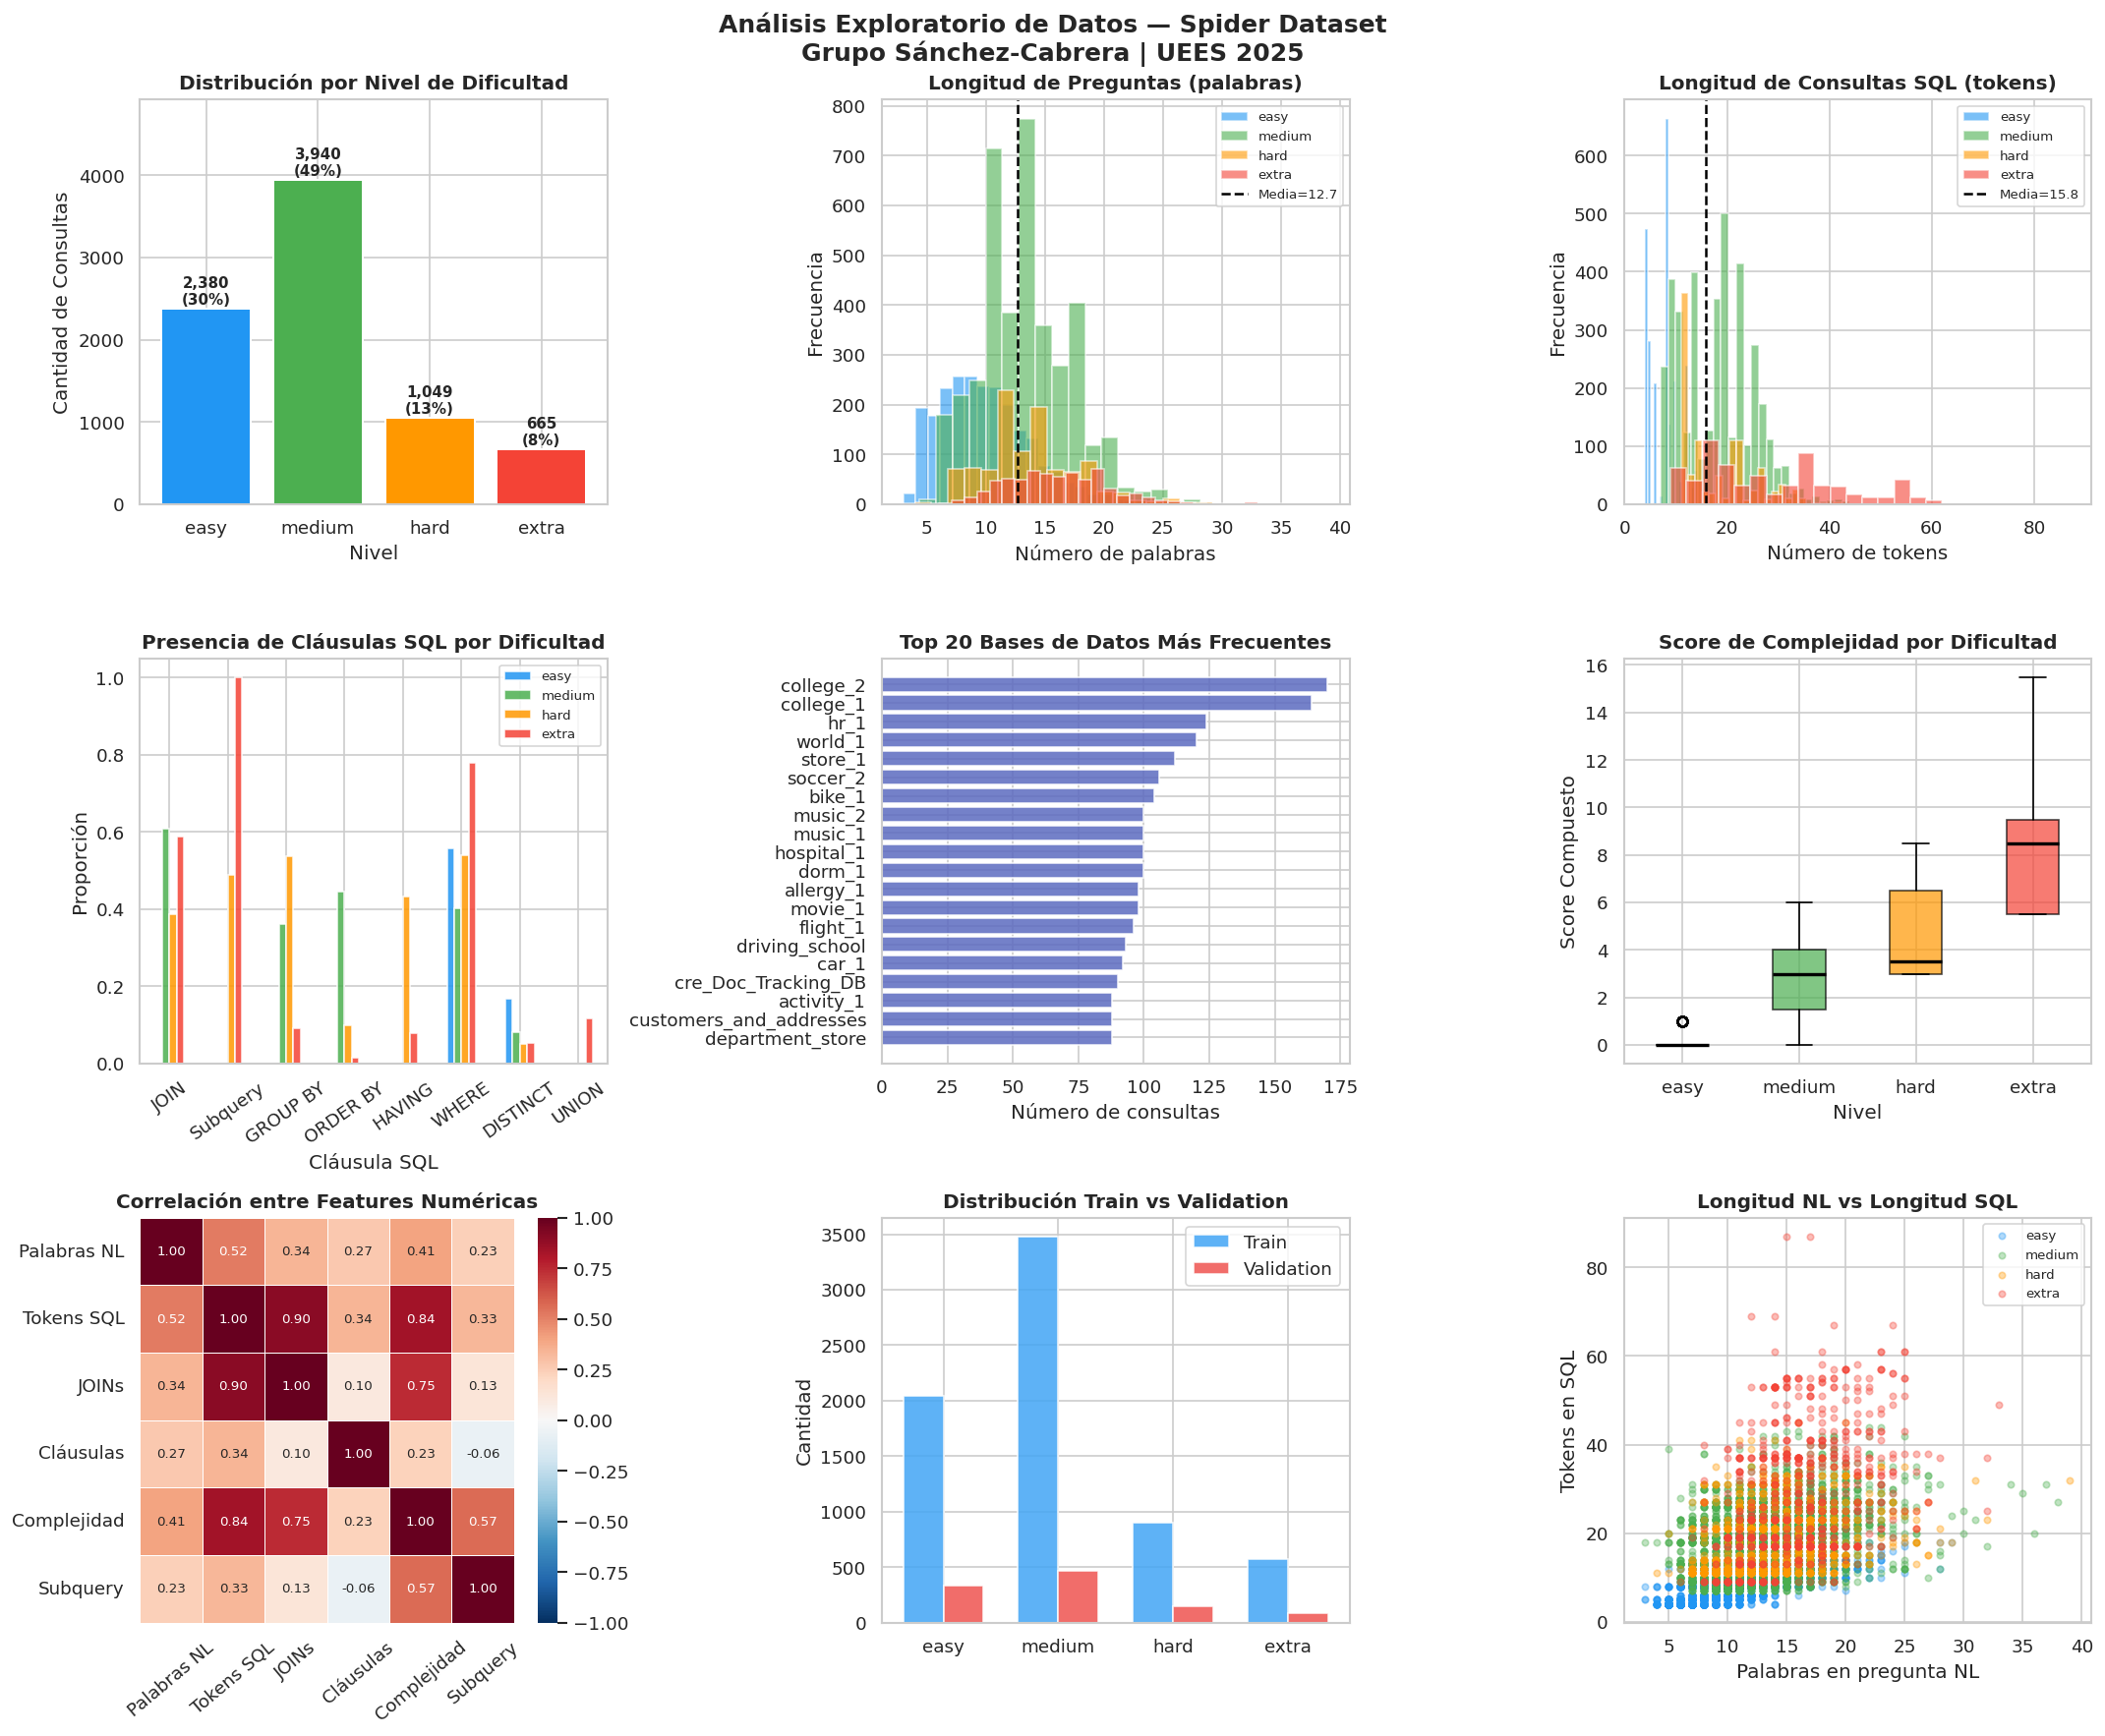

✅ Visualización EDA guardada como 'eda_spider_completo.png'


In [8]:
# ─── 2.4 Visualizaciones EDA ──────────────────────────────────────────────────
# Panel visual completo del análisis exploratorio

diff_colors = {'easy': '#2196F3', 'medium': '#4CAF50', 'hard': '#FF9800', 'extra': '#F44336'}

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Análisis Exploratorio de Datos — Spider Dataset\nGrupo Sánchez-Cabrera | UEES 2025',
             fontsize=15, fontweight='bold', y=0.98)

# ── (1) Distribución de dificultad ──
ax = axes[0, 0]
counts  = [diff_counts[d] for d in diff_order]
colors  = [diff_colors[d] for d in diff_order]
bars = ax.bar(diff_order, counts, color=colors, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{cnt:,}\n({cnt/len(df_all)*100:.0f}%)',
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('Distribución por Nivel de Dificultad', fontweight='bold')
ax.set_xlabel('Nivel'); ax.set_ylabel('Cantidad de Consultas')
ax.set_ylim(0, max(counts) * 1.25)

# ── (2) Distribución de longitud de preguntas NL ──
ax = axes[0, 1]
for diff in diff_order:
    subset = df_all[df_all['difficulty'] == diff]['question_word_count']
    ax.hist(subset, bins=25, alpha=0.6, label=diff, color=diff_colors[diff])
ax.axvline(df_all['question_word_count'].mean(), color='black', linestyle='--',
           linewidth=1.5, label=f'Media={df_all["question_word_count"].mean():.1f}')
ax.set_title('Longitud de Preguntas (palabras)', fontweight='bold')
ax.set_xlabel('Número de palabras'); ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)

# ── (3) Distribución de longitud SQL ──
ax = axes[0, 2]
for diff in diff_order:
    subset = df_all[df_all['difficulty'] == diff]['sql_token_count']
    ax.hist(subset, bins=25, alpha=0.6, label=diff, color=diff_colors[diff])
ax.axvline(df_all['sql_token_count'].mean(), color='black', linestyle='--',
           linewidth=1.5, label=f'Media={df_all["sql_token_count"].mean():.1f}')
ax.set_title('Longitud de Consultas SQL (tokens)', fontweight='bold')
ax.set_xlabel('Número de tokens'); ax.set_ylabel('Frecuencia')
ax.legend(fontsize=8)

# ── (4) Presencia de cláusulas SQL por nivel ──
ax = axes[1, 0]
clause_cols = ['has_join','has_subquery','has_group_by','has_order_by',
               'has_having','has_where','has_distinct','has_union']
clause_by_diff = df_all.groupby('difficulty')[clause_cols].mean().reindex(diff_order)
clause_by_diff.columns = ['JOIN','Subquery','GROUP BY','ORDER BY',
                           'HAVING','WHERE','DISTINCT','UNION']
clause_by_diff.T.plot(kind='bar', ax=ax, color=colors, alpha=0.85, edgecolor='white')
ax.set_title('Presencia de Cláusulas SQL por Dificultad', fontweight='bold')
ax.set_xlabel('Cláusula SQL'); ax.set_ylabel('Proporción')
ax.legend(diff_order, fontsize=8)
ax.tick_params(axis='x', rotation=35)

# ── (5) Top 20 bases de datos ──
ax = axes[1, 1]
top_dbs = df_all['db_id'].value_counts().head(20)
ax.barh(top_dbs.index[::-1], top_dbs.values[::-1], color='#5C6BC0', alpha=0.85)
ax.set_title('Top 20 Bases de Datos Más Frecuentes', fontweight='bold')
ax.set_xlabel('Número de consultas')

# ── (6) Score de complejidad por dificultad ──
ax = axes[1, 2]
data_box = [df_all[df_all['difficulty']==d]['complexity_score'].values for d in diff_order]
bp = ax.boxplot(data_box, labels=diff_order, patch_artist=True,
                medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_title('Score de Complejidad por Dificultad', fontweight='bold')
ax.set_xlabel('Nivel'); ax.set_ylabel('Score Compuesto')

# ── (7) Correlación entre features numéricas ──
ax = axes[2, 0]
corr_cols = ['question_word_count','sql_token_count','join_count',
             'clause_count','complexity_score','has_subquery']
corr_labels = ['Palabras NL','Tokens SQL','JOINs','Cláusulas','Complejidad','Subquery']
corr_matrix = df_all[corr_cols].corr()
corr_matrix.columns = corr_labels
corr_matrix.index   = corr_labels
sns.heatmap(corr_matrix, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size':8})
ax.set_title('Correlación entre Features Numéricas', fontweight='bold')
ax.tick_params(axis='x', rotation=40)

# ── (8) Distribución train vs validation ──
ax = axes[2, 1]
train_diff = df_all[df_all['split']=='train']['difficulty'].value_counts().reindex(diff_order)
val_diff   = df_all[df_all['split']=='validation']['difficulty'].value_counts().reindex(diff_order)
x = np.arange(len(diff_order)); width = 0.35
ax.bar(x - width/2, train_diff.values, width, label='Train',
       color='#42A5F5', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, val_diff.values,   width, label='Validation',
       color='#EF5350', alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(diff_order)
ax.set_title('Distribución Train vs Validation', fontweight='bold')
ax.set_ylabel('Cantidad'); ax.legend()

# ── (9) Scatter: longitud NL vs SQL, coloreado por dificultad ──
ax = axes[2, 2]
for diff in diff_order:
    subset = df_all[df_all['difficulty'] == diff]
    ax.scatter(subset['question_word_count'], subset['sql_token_count'],
               c=diff_colors[diff], label=diff, alpha=0.35, s=15)
ax.set_title('Longitud NL vs Longitud SQL', fontweight='bold')
ax.set_xlabel('Palabras en pregunta NL'); ax.set_ylabel('Tokens en SQL')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_spider_completo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualización EDA guardada como 'eda_spider_completo.png'")

In [9]:
# ─── 2.5 Análisis de Calidad de Datos ─────────────────────────────────────────
# Identificamos problemas de calidad que deben ser tratados en el pipeline de limpieza

print("=" * 70)
print("REPORTE DE CALIDAD DE DATOS")
print("=" * 70)

# 1. Valores nulos
null_report = df_all.isnull().sum()
print(f"\n1. Valores nulos: {null_report.sum()} total")
print(null_report[null_report > 0] if null_report.sum() > 0 else "   ✅ Sin valores nulos")

# 2. Duplicados
dup_exact = df_all.duplicated(subset=['question', 'query']).sum()
dup_q     = df_all.duplicated(subset=['question']).sum()
dup_sql   = df_all.duplicated(subset=['query']).sum()
print(f"\n2. Duplicados:")
print(f"   Pares (pregunta+SQL) exactos : {dup_exact}")
print(f"   Preguntas duplicadas         : {dup_q}")
print(f"   Consultas SQL duplicadas     : {dup_sql}")
print(f"   (Una misma SQL puede tener múltiples preguntas equivalentes — es esperado)")

# 3. Preguntas demasiado cortas o largas (outliers)
q_low  = (df_all['question_word_count'] < 3).sum()
q_high = (df_all['question_word_count'] > 40).sum()
print(f"\n3. Outliers en longitud de preguntas:")
print(f"   Preguntas < 3 palabras  : {q_low}")
print(f"   Preguntas > 40 palabras : {q_high}")

# 4. SQL vacíos o malformados
sql_empty  = (df_all['query'].str.strip() == '').sum()
sql_nosel  = (~df_all['query'].str.upper().str.contains('SELECT')).sum()
print(f"\n4. Calidad SQL:")
print(f"   SQL vacíos            : {sql_empty}")
print(f"   SQL sin SELECT        : {sql_nosel}")

# 5. Distribución de caracteres especiales en preguntas
has_special = df_all['question'].str.contains(r'[^a-zA-Z0-9\s\?\.,\'"\-]', regex=True).sum()
print(f"\n5. Preguntas con caracteres especiales: {has_special}")

print(f"\n📋 RESUMEN:")
print(f"   El dataset Spider presenta alta calidad de base.")
print(f"   Los duplicados SQL son esperados (paráfrasis naturales).")
print(f"   No hay valores nulos — dataset listo para limpieza fina.")

REPORTE DE CALIDAD DE DATOS

1. Valores nulos: 0 total
   ✅ Sin valores nulos

2. Duplicados:
   Pares (pregunta+SQL) exactos : 21
   Preguntas duplicadas         : 44
   Consultas SQL duplicadas     : 3509
   (Una misma SQL puede tener múltiples preguntas equivalentes — es esperado)

3. Outliers en longitud de preguntas:
   Preguntas < 3 palabras  : 0
   Preguntas > 40 palabras : 0

4. Calidad SQL:
   SQL vacíos            : 0
   SQL sin SELECT        : 0

5. Preguntas con caracteres especiales: 136

📋 RESUMEN:
   El dataset Spider presenta alta calidad de base.
   Los duplicados SQL son esperados (paráfrasis naturales).
   No hay valores nulos — dataset listo para limpieza fina.


---
## 3. Pipeline de Limpieza de Datos

Basándonos en los hallazgos del EDA, implementamos un pipeline de limpieza sistemático.
Cada paso está justificado y documentado para garantizar reproducibilidad y trazabilidad.

Los pasos de limpieza son:
1. Normalización de texto en preguntas NL
2. Normalización de consultas SQL
3. Eliminación de duplicados estratégica
4. Filtrado de outliers justificado
5. Validación de consistencia

In [10]:
# ─── 3.1 Normalización de preguntas en lenguaje natural ───────────────────────

import unicodedata
import string

def clean_question(text):
    """
    Limpieza y normalización de preguntas en lenguaje natural.
    Pipeline: unicode → strip → espacios → puntuación al final.

    NO eliminamos stopwords aquí porque para Text-to-SQL las stopwords
    pueden ser semánticamente relevantes (ej: 'NOT', 'AND', 'OR' en preguntas).
    """
    if pd.isna(text):
        return text

    # Normalización Unicode (NFC: forma canónica compuesta)
    text = unicodedata.normalize('NFC', str(text))

    # Eliminar espacios al inicio/fin y espacios múltiples
    text = ' '.join(text.split())

    # Capitalizar primera letra (consistencia)
    text = text[0].upper() + text[1:] if len(text) > 0 else text

    # Asegurar que la pregunta termine con signo de interrogación
    text = text.rstrip('.')
    if not text.endswith('?'):
        text = text + '?'

    return text


def normalize_sql(sql):
    """
    Normalización de consultas SQL para consistencia.
    Pipeline: uppercase keywords → espacios → formato sqlparse.

    Objetivo: dos SQLs semánticamente equivalentes deben tener
    la misma representación textual post-normalización.
    """
    if pd.isna(sql):
        return sql

    sql = str(sql).strip()

    # Usar sqlparse para formateo estándar
    try:
        sql_parsed = sqlparse.format(
            sql,
            keyword_case='upper',   # Keywords en mayúsculas
            identifier_case='lower', # Identificadores en minúsculas
            strip_comments=True,
            strip_whitespace=True,
        )
    except Exception:
        sql_parsed = sql.upper()  # Fallback simple

    # Eliminar punto y coma final (inconsistencia frecuente)
    sql_parsed = sql_parsed.rstrip(';').strip()

    return sql_parsed


# Aplicar limpieza al dataset de train (el que usaremos para modelado)
print("⏳ Aplicando pipeline de limpieza...")

df_clean = df_all.copy()
n_original = len(df_clean)

# Paso 1: Normalización de texto
df_clean['question_clean'] = df_clean['question'].apply(clean_question)
df_clean['query_clean']    = df_clean['query'].apply(normalize_sql)

print(f"   ✅ Paso 1: Normalización de texto completada.")

# Paso 2: Eliminación de duplicados exactos (pregunta + SQL idénticos)
# JUSTIFICACIÓN: duplicados exactos no aportan información nueva al modelo
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['question_clean', 'query_clean'])
n_dup_removed = n_before - len(df_clean)
print(f"   ✅ Paso 2: {n_dup_removed} duplicados exactos eliminados.")

# Paso 3: Filtrar preguntas extremadamente cortas (< 3 palabras)
# JUSTIFICACIÓN: preguntas < 3 palabras no proveen suficiente contexto semántico
n_before = len(df_clean)
df_clean = df_clean[df_clean['question_word_count'] >= 3]
print(f"   ✅ Paso 3: {n_before - len(df_clean)} preguntas < 3 palabras removidas.")

# Paso 4: Filtrar SQLs sin SELECT (malformados)
n_before = len(df_clean)
df_clean = df_clean[df_clean['query_clean'].str.upper().str.contains('SELECT', na=False)]
print(f"   ✅ Paso 4: {n_before - len(df_clean)} SQLs malformados removidos.")

# Paso 5: Reset de índice
df_clean = df_clean.reset_index(drop=True)

print(f"\n📊 Resumen de limpieza:")
print(f"   Registros originales : {n_original:,}")
print(f"   Registros finales    : {len(df_clean):,}")
print(f"   Registros removidos  : {n_original - len(df_clean):,} ({(n_original-len(df_clean))/n_original*100:.2f}%)")
print(f"   Integridad del dato  : {len(df_clean)/n_original*100:.1f}% conservada")

⏳ Aplicando pipeline de limpieza...
   ✅ Paso 1: Normalización de texto completada.
   ✅ Paso 2: 33 duplicados exactos eliminados.
   ✅ Paso 3: 0 preguntas < 3 palabras removidas.
   ✅ Paso 4: 0 SQLs malformados removidos.

📊 Resumen de limpieza:
   Registros originales : 8,034
   Registros finales    : 8,001
   Registros removidos  : 33 (0.41%)
   Integridad del dato  : 99.6% conservada


In [11]:
# ─── 3.2 Reporte de limpieza antes/después ────────────────────────────────────
# Comparamos las estadísticas antes y después de la limpieza

print("=" * 60)
print("COMPARACIÓN ANTES vs DESPUÉS DE LIMPIEZA")
print("=" * 60)

compare = pd.DataFrame({
    'Antes': [
        len(df_all),
        df_all['question_word_count'].mean(),
        df_all['sql_token_count'].mean(),
        df_all['db_id'].nunique(),
        df_all.duplicated(subset=['question','query']).sum()
    ],
    'Después': [
        len(df_clean),
        df_clean['question_word_count'].mean(),
        df_clean['sql_token_count'].mean(),
        df_clean['db_id'].nunique(),
        df_clean.duplicated(subset=['question_clean','query_clean']).sum()
    ]
}, index=['N registros','Media palabras NL','Media tokens SQL',
          'DBs únicas','Duplicados exactos'])

compare['Diferencia'] = (compare['Después'] - compare['Antes']).round(2)
print(compare.round(2).to_string())

# Ejemplo de normalización SQL visible
print("\n📋 Ejemplo de normalización SQL:")
idx = df_clean.index[0]
print(f"   ORIGINAL : {df_all.loc[0, 'query'][:80]}")
print(f"   LIMPIO   : {df_clean.loc[0, 'query_clean'][:80]}")

COMPARACIÓN ANTES vs DESPUÉS DE LIMPIEZA
                      Antes  Después  Diferencia
N registros         8034.00  8001.00      -33.00
Media palabras NL     12.69    12.71        0.02
Media tokens SQL      15.85    15.88        0.04
DBs únicas           160.00   160.00        0.00
Duplicados exactos    21.00     0.00      -21.00

📋 Ejemplo de normalización SQL:
   ORIGINAL : SELECT count(*) FROM head WHERE age  >  56
   LIMPIO   : SELECT count(*) FROM head WHERE age > 56


---
## 4. Feature Engineering Avanzado

El Feature Engineering transforma los datos crudos en representaciones numéricas
que los modelos de ML pueden procesar. Para Text-to-SQL, creamos tres familias de features:

1. **Features lingüísticas**: sobre la pregunta en lenguaje natural
2. **Features estructurales SQL**: sobre la consulta objetivo
3. **Features de interacción**: relación entre pregunta y SQL
4. **Embeddings de texto**: representaciones vectoriales densas (TF-IDF)

In [12]:
# ─── 4.1 Features lingüísticas de la pregunta NL ─────────────────────────────

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

stop_words_en = set(stopwords.words('english'))

# Palabras interrogativas relevantes para Text-to-SQL
WH_WORDS    = {'what', 'which', 'who', 'where', 'when', 'how', 'whose'}
AGG_WORDS   = {'many', 'much', 'average', 'total', 'sum', 'count',
               'maximum', 'minimum', 'highest', 'lowest', 'most', 'least'}
COMP_WORDS  = {'more', 'less', 'greater', 'smaller', 'between', 'except',
               'not', 'without', 'other', 'different', 'same'}
ORDER_WORDS = {'order', 'sort', 'rank', 'list', 'top', 'bottom', 'first', 'last'}

def extract_linguistic_features(question):
    """Extrae features lingüísticas de la pregunta en lenguaje natural."""
    if pd.isna(question):
        return {}

    q_lower  = str(question).lower()
    tokens   = word_tokenize(q_lower)
    words    = [t for t in tokens if t.isalpha()]
    non_stop = [w for w in words if w not in stop_words_en]

    return {
        # Métricas básicas
        'nl_word_count'         : len(words),
        'nl_unique_words'       : len(set(words)),
        'nl_lexical_diversity'  : len(set(words)) / max(len(words), 1),
        'nl_non_stop_ratio'     : len(non_stop) / max(len(words), 1),
        'nl_avg_word_length'    : np.mean([len(w) for w in words]) if words else 0,
        'nl_question_marks'     : question.count('?'),
        'nl_has_number'         : int(any(t.isdigit() for t in tokens)),
        'nl_number_count'       : sum(1 for t in tokens if t.isdigit()),

        # Features semánticas para Text-to-SQL
        'nl_has_wh_word'        : int(any(w in WH_WORDS for w in words)),
        'nl_has_agg_word'       : int(any(w in AGG_WORDS for w in words)),
        'nl_has_comparison_word': int(any(w in COMP_WORDS for w in words)),
        'nl_has_order_word'     : int(any(w in ORDER_WORDS for w in words)),

        # Palabras clave para JOINs implícitos
        'nl_has_join_signal'    : int(any(w in {'across','between','with','related','linked'}
                                          for w in words)),

        # Complejidad estructural de la pregunta
        'nl_comma_count'        : question.count(','),
        'nl_and_count'          : q_lower.count(' and '),
        'nl_or_count'           : q_lower.count(' or '),
    }

print("⏳ Extrayendo features lingüísticas...")
tqdm.pandas(desc="Features lingüísticas")
ling_features = df_clean['question_clean'].progress_apply(extract_linguistic_features)
df_ling = pd.DataFrame(ling_features.tolist())

print(f"✅ {len(df_ling.columns)} features lingüísticas generadas.")
print(f"   Features: {list(df_ling.columns)}")

⏳ Extrayendo features lingüísticas...


Features lingüísticas:   0%|          | 0/8001 [00:00<?, ?it/s]

✅ 16 features lingüísticas generadas.
   Features: ['nl_word_count', 'nl_unique_words', 'nl_lexical_diversity', 'nl_non_stop_ratio', 'nl_avg_word_length', 'nl_question_marks', 'nl_has_number', 'nl_number_count', 'nl_has_wh_word', 'nl_has_agg_word', 'nl_has_comparison_word', 'nl_has_order_word', 'nl_has_join_signal', 'nl_comma_count', 'nl_and_count', 'nl_or_count']


In [13]:
# ─── 4.2 Features avanzadas de SQL ────────────────────────────────────────────

SQL_KEYWORDS = [
    'SELECT','FROM','WHERE','JOIN','LEFT JOIN','RIGHT JOIN','INNER JOIN',
    'OUTER JOIN','GROUP BY','ORDER BY','HAVING','LIMIT','UNION','INTERSECT',
    'EXCEPT','DISTINCT','COUNT','SUM','AVG','MAX','MIN','NOT IN','IN',
    'EXISTS','BETWEEN','LIKE','IS NULL','IS NOT NULL','ASC','DESC'
]

def extract_advanced_sql_features(sql):
    """Extrae features estructurales avanzadas de una consulta SQL."""
    if pd.isna(sql):
        return {}

    sql_u = str(sql).upper()

    # Contar tablas referenciadas (aproximación por FROM y JOIN)
    from_matches = re.findall(r'FROM\s+(\w+)', sql_u)
    join_matches = re.findall(r'JOIN\s+(\w+)', sql_u)
    tables_referenced = len(set(from_matches + join_matches))

    # Contar columnas en SELECT
    select_part = sql_u.split('FROM')[0].replace('SELECT', '').strip()
    if select_part == '*':
        col_count = -1  # SELECT * = desconocido
    else:
        col_count = len(select_part.split(','))

    # Contar condiciones WHERE
    where_conditions = 0
    if 'WHERE' in sql_u:
        where_part = sql_u.split('WHERE')[1].split('GROUP BY')[0].split('ORDER BY')[0]
        where_conditions = where_part.count(' AND ') + where_part.count(' OR ') + 1

    # Profundidad de anidamiento (subconsultas)
    nesting_depth = sql_u.count('SELECT') - 1

    # Tipo de JOIN predominante
    join_type = 'none'
    if 'LEFT JOIN' in sql_u:   join_type = 'left'
    elif 'RIGHT JOIN' in sql_u: join_type = 'right'
    elif 'INNER JOIN' in sql_u: join_type = 'inner'
    elif 'JOIN' in sql_u:       join_type = 'implicit'

    return {
        # Complejidad estructural
        'sql_nesting_depth'      : max(0, nesting_depth),
        'sql_tables_referenced'  : tables_referenced,
        'sql_col_count_select'   : col_count,
        'sql_where_conditions'   : where_conditions,
        'sql_total_keywords'     : sum(1 for kw in SQL_KEYWORDS if kw in sql_u),

        # Tipo de operaciones
        'sql_join_type_none'     : int(join_type == 'none'),
        'sql_join_type_inner'    : int(join_type in ('inner','implicit')),
        'sql_join_type_left'     : int(join_type == 'left'),
        'sql_join_type_right'    : int(join_type == 'right'),

        # Predicados de filtro
        'sql_has_in_clause'      : int(' IN ' in sql_u or ' NOT IN ' in sql_u),
        'sql_has_like'           : int('LIKE' in sql_u),
        'sql_has_null_check'     : int('IS NULL' in sql_u or 'IS NOT NULL' in sql_u),
        'sql_has_between'        : int('BETWEEN' in sql_u),
        'sql_has_exists'         : int('EXISTS' in sql_u),

        # Ordenamiento y agrupación
        'sql_has_asc'            : int(' ASC' in sql_u),
        'sql_has_desc'           : int(' DESC' in sql_u),
        'sql_select_star'        : int('SELECT *' in sql_u or 'SELECT DISTINCT *' in sql_u),
    }

print("⏳ Extrayendo features SQL avanzadas...")
tqdm.pandas(desc="Features SQL avanzadas")
adv_sql_features = df_clean['query_clean'].progress_apply(extract_advanced_sql_features)
df_adv_sql = pd.DataFrame(adv_sql_features.tolist())

print(f"✅ {len(df_adv_sql.columns)} features SQL avanzadas generadas.")

⏳ Extrayendo features SQL avanzadas...


Features SQL avanzadas:   0%|          | 0/8001 [00:00<?, ?it/s]

✅ 17 features SQL avanzadas generadas.


In [14]:
# ─── 4.3 Features de interacción NL-SQL y encoding de dificultad ──────────────

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Dataset con todas las features
df_featured = pd.concat([
    df_clean[['question_clean','query_clean','db_id','difficulty','split',
              'question_word_count','sql_token_count','complexity_score',
              'has_join','has_subquery','has_group_by','has_order_by',
              'has_having','has_where','has_distinct','has_union','join_count']],
    df_ling.reset_index(drop=True),
    df_adv_sql.reset_index(drop=True)
], axis=1)

# Features de interacción (relación entre NL y SQL)
df_featured['ratio_nl_sql_length'] = (
    df_featured['question_word_count'] / df_featured['sql_token_count'].replace(0, 1)
)
df_featured['interaction_score'] = (
    df_featured['nl_has_agg_word'] * df_featured['has_group_by'] +
    df_featured['nl_has_order_word'] * df_featured['has_order_by'] +
    df_featured['nl_has_join_signal'] * df_featured['has_join'] +
    df_featured['nl_has_comparison_word'] * df_featured['has_having']
)
df_featured['sql_complexity_per_word'] = (
    df_featured['complexity_score'] / df_featured['nl_word_count'].replace(0, 1)
)

# Encoding de la variable objetivo (dificultad)
diff_map     = {'easy': 0, 'medium': 1, 'hard': 2, 'extra': 3}
diff_map_inv = {v: k for k, v in diff_map.items()}
df_featured['difficulty_encoded'] = df_featured['difficulty'].map(diff_map)

# Encoding del db_id (para capturar dominio)
le_db = LabelEncoder()
df_featured['db_id_encoded'] = le_db.fit_transform(df_featured['db_id'].fillna('unknown'))

# Columnas numéricas finales para modelado
numeric_feature_cols = [c for c in df_featured.columns
                        if df_featured[c].dtype in ['int64','float64','int32','float32']
                        and c not in ['difficulty_encoded','db_id_encoded']]

print(f"✅ Dataset de features completo generado.")
print(f"   Total registros   : {len(df_featured):,}")
print(f"   Total features    : {len(df_featured.columns)}")
print(f"   Features numéricas: {len(numeric_feature_cols)}")
print(f"   Variable objetivo : difficulty_encoded (0=easy, 1=medium, 2=hard, 3=extra)")
print(f"\nPrimeras 5 filas del dataset de features:")
display_cols = ['question_clean','difficulty','difficulty_encoded',
                'nl_word_count','sql_token_count','complexity_score',
                'nl_has_agg_word','has_join','sql_nesting_depth']
print(df_featured[display_cols].head())

✅ Dataset de features completo generado.
   Total registros   : 8,001
   Total features    : 55
   Features numéricas: 48
   Variable objetivo : difficulty_encoded (0=easy, 1=medium, 2=hard, 3=extra)

Primeras 5 filas del dataset de features:
                                      question_clean difficulty  \
0  How many heads of the departments are older th...       easy   
1  List the name, born state and age of the heads...     medium   
2  List the creation year, name and budget of eac...       easy   
3  What are the maximum and minimum budget of the...       easy   
4  What is the average number of employees of the...       easy   

   difficulty_encoded  nl_word_count  sql_token_count  complexity_score  \
0                   0              9                8               0.0   
1                   1             15               11               0.0   
2                   0             10                8               0.0   
3                   0             10                6 

Features con varianza > 0: 44 de 48


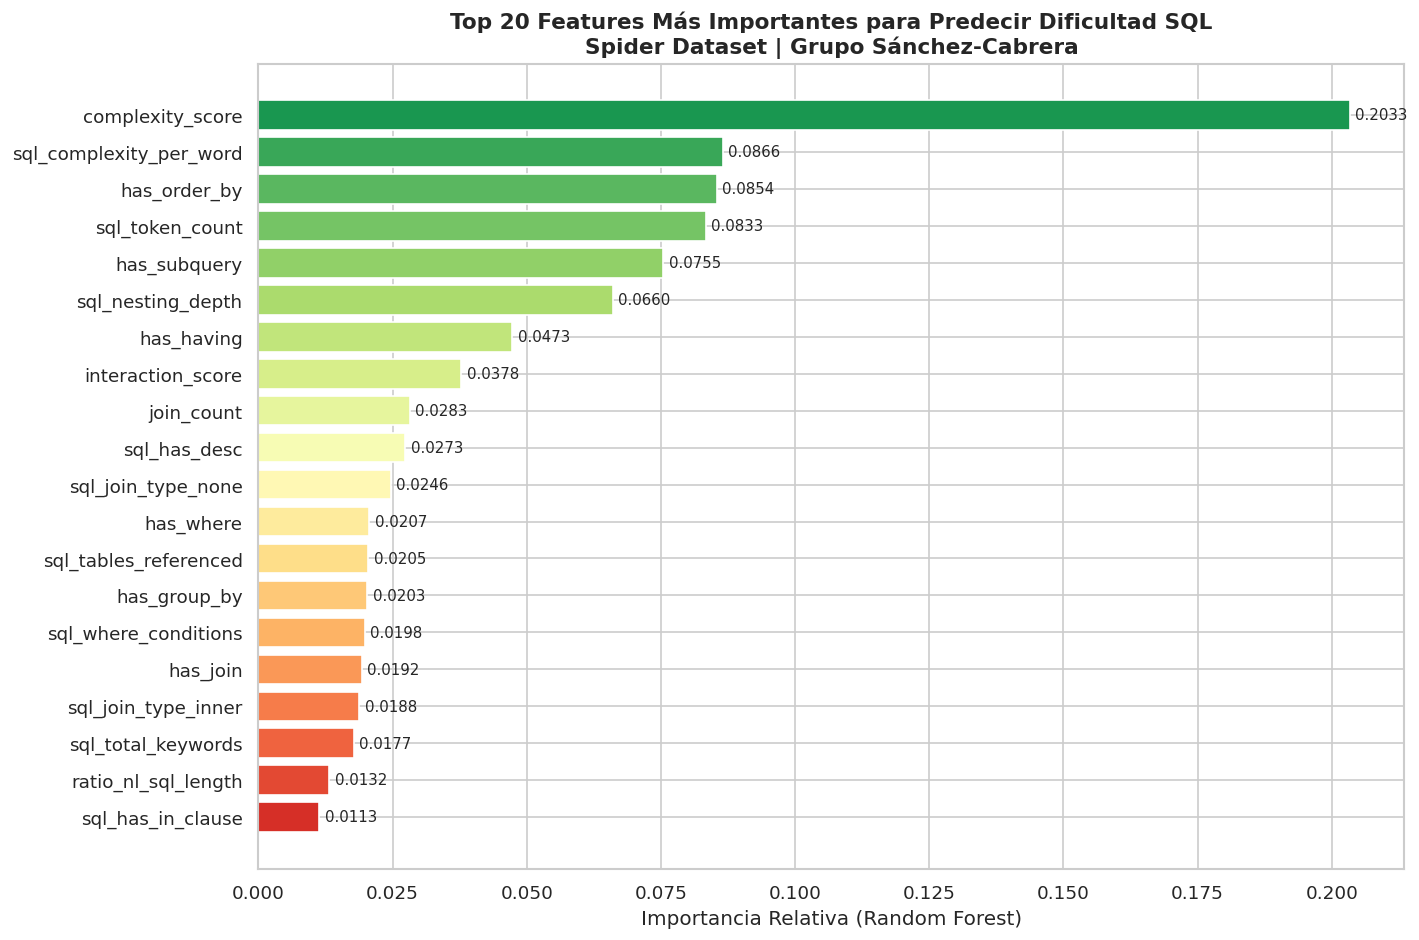


📊 Top 10 features más importantes:
   complexity_score                        : 0.2033
   sql_complexity_per_word                 : 0.0866
   has_order_by                            : 0.0854
   sql_token_count                         : 0.0833
   has_subquery                            : 0.0755
   sql_nesting_depth                       : 0.0660
   has_having                              : 0.0473
   interaction_score                       : 0.0378
   join_count                              : 0.0283
   sql_has_desc                            : 0.0273


In [15]:
# ─── 4.4 Análisis de importancia de features ──────────────────────────────────
# Usamos Random Forest para estimar la importancia relativa de las features
# antes de aplicar el pipeline de modelado completo.

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Preparar datos para análisis de importancia
X_imp = df_featured[numeric_feature_cols].fillna(0)
y_imp = df_featured['difficulty_encoded']

# Eliminar features con varianza cero (no aportan información)
var_filter  = X_imp.var() > 0
X_imp_clean = X_imp.loc[:, var_filter]
print(f"Features con varianza > 0: {X_imp_clean.shape[1]} de {X_imp.shape[1]}")

# Entrenar RF rápido para importancia
rf_imp = RandomForestClassifier(n_estimators=100, max_depth=8,
                                random_state=42, n_jobs=-1)
rf_imp.fit(X_imp_clean, y_imp)

# Ordenar por importancia
importances = pd.Series(rf_imp.feature_importances_,
                        index=X_imp_clean.columns).sort_values(ascending=False)

# Visualización
fig, ax = plt.subplots(figsize=(12, 8))
top_n = 20
top_features = importances.head(top_n)
colors_imp = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, top_n))
bars = ax.barh(top_features.index[::-1], top_features.values[::-1],
               color=colors_imp[::-1], edgecolor='white')
ax.set_xlabel('Importancia Relativa (Random Forest)', fontsize=12)
ax.set_title(f'Top {top_n} Features Más Importantes para Predecir Dificultad SQL\n'
             f'Spider Dataset | Grupo Sánchez-Cabrera',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance_spider.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Top 10 features más importantes:")
for feat, imp in importances.head(10).items():
    print(f"   {feat:40s}: {imp:.4f}")

---
## 5. Estrategias de Balanceamiento de Datos

El EDA reveló un desbalance significativo en la distribución de dificultad.
Las consultas 'extra hard' representan solo ~11% del dataset, lo que puede
llevar a modelos sesgados hacia las clases mayoritarias.

Implementamos y comparamos tres estrategias:
1. **Class Weights**: ajuste de pesos sin modificar los datos
2. **SMOTE**: sobremuestreo sintético de la minoría
3. **Undersampling + Oversampling combinado**: balance híbrido

In [16]:
# ─── 5.1 Diagnóstico del desbalance ───────────────────────────────────────────

from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Separar por split para aplicar balanceo solo al train
df_train_feat = df_featured[df_featured['split'] == 'train'].copy()
df_val_feat   = df_featured[df_featured['split'] == 'validation'].copy()

X_train = df_train_feat[X_imp_clean.columns].fillna(0)
y_train = df_train_feat['difficulty_encoded']
X_val   = df_val_feat[X_imp_clean.columns].fillna(0)
y_val   = df_val_feat['difficulty_encoded']

# Diagnóstico del desbalance
print("=" * 60)
print("DIAGNÓSTICO DE DESBALANCE DE CLASES — SPLIT TRAIN")
print("=" * 60)

dist = y_train.value_counts().sort_index()
total = len(y_train)
for cls, cnt in dist.items():
    label = diff_map_inv.get(cls, str(cls))
    ratio = cnt / total
    bar   = '█' * int(ratio * 50)
    print(f"   Clase {cls} ({label:8s}): {cnt:5,} ({ratio*100:5.1f}%) {bar}")

# Ratio de desbalance (clase mayoritaria / minoritaria)
ratio_imb = dist.max() / dist.min()
print(f"\n   Ratio de desbalance (max/min): {ratio_imb:.1f}x")
print(f"   Umbral problemático           : > 3x")
print(f"   Estado                        : {'⚠️  DESBALANCEADO' if ratio_imb > 3 else '✅ Aceptable'}")

DIAGNÓSTICO DE DESBALANCE DE CLASES — SPLIT TRAIN
   Clase 0 (easy    ): 2,024 ( 29.0%) ██████████████
   Clase 1 (medium  ): 3,472 ( 49.8%) ████████████████████████
   Clase 2 (hard    ):   896 ( 12.9%) ██████
   Clase 3 (extra   ):   577 (  8.3%) ████

   Ratio de desbalance (max/min): 6.0x
   Umbral problemático           : > 3x
   Estado                        : ⚠️  DESBALANCEADO


In [17]:
# ─── 5.2 Estrategia 1: Class Weights (sin modificar datos) ────────────────────
# La forma más simple y segura: asignamos pesos inversamente proporcionales
# a la frecuencia de cada clase. No genera datos artificiales.

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Estrategia 1: Class Weights (recomendada para LLMs/Transformers)")
print("-" * 55)
for cls, w in class_weight_dict.items():
    label = diff_map_inv.get(cls, str(cls))
    print(f"   Clase {cls} ({label:8s}): peso = {w:.4f}")

print("\n   ✅ Ventaja: No altera la distribución real de los datos.")
print("   ✅ Ideal para fine-tuning de modelos LLM (CodeLlama, LLaMA-3).")
print("   ⚠️  Requiere soporte en la función de pérdida del modelo.")

Estrategia 1: Class Weights (recomendada para LLMs/Transformers)
-------------------------------------------------------
   Clase 0 (easy    ): peso = 0.8608
   Clase 1 (medium  ): peso = 0.5018
   Clase 2 (hard    ): peso = 1.9445
   Clase 3 (extra   ): peso = 3.0195

   ✅ Ventaja: No altera la distribución real de los datos.
   ✅ Ideal para fine-tuning de modelos LLM (CodeLlama, LLaMA-3).
   ⚠️  Requiere soporte en la función de pérdida del modelo.


In [18]:
# ─── 5.3 Estrategia 2: SMOTE ──────────────────────────────────────────────────
# Synthetic Minority Over-sampling Technique: genera ejemplos sintéticos
# interpolando entre vecinos cercanos en el espacio de features.
# NOTA: SMOTE opera sobre features numéricas, no sobre texto directamente.

print("Estrategia 2: SMOTE (Synthetic Minority Over-sampling)")
print("-" * 55)

# SMOTE requiere al menos k_neighbors+1 ejemplos por clase
k_neighbors = min(5, dist.min() - 1)
smote = SMOTE(k_neighbors=k_neighbors, random_state=42)

try:
    X_smote, y_smote = smote.fit_resample(X_train, y_train)
    dist_smote = pd.Series(y_smote).value_counts().sort_index()
    print(f"   Registros originales : {len(y_train):,}")
    print(f"   Registros post-SMOTE : {len(y_smote):,}")
    print(f"   Registros sintéticos : {len(y_smote) - len(y_train):,}")
    print(f"\n   Distribución post-SMOTE:")
    for cls, cnt in dist_smote.items():
        label = diff_map_inv.get(cls, str(cls))
        print(f"     Clase {cls} ({label:8s}): {cnt:,}")
    print("\n   ✅ SMOTE funciona bien para clasificación con features numéricas.")
    print("   ⚠️  No genera texto NL nuevo — los features sintetizados son interpolaciones.")
except Exception as e:
    print(f"   ⚠️  SMOTE no aplicable: {e}")
    X_smote, y_smote = X_train.copy(), y_train.copy()

Estrategia 2: SMOTE (Synthetic Minority Over-sampling)
-------------------------------------------------------
   Registros originales : 6,969
   Registros post-SMOTE : 13,888
   Registros sintéticos : 6,919

   Distribución post-SMOTE:
     Clase 0 (easy    ): 3,472
     Clase 1 (medium  ): 3,472
     Clase 2 (hard    ): 3,472
     Clase 3 (extra   ): 3,472

   ✅ SMOTE funciona bien para clasificación con features numéricas.
   ⚠️  No genera texto NL nuevo — los features sintetizados son interpolaciones.


Estrategia 3: SMOTETomek (Combinada)
-------------------------------------------------------
   Registros originales      : 6,969
   Registros post-SMOTETomek : 13,886

   Distribución:
     Clase 0 (easy    ): 3,471
     Clase 1 (medium  ): 3,471
     Clase 2 (hard    ): 3,472
     Clase 3 (extra   ): 3,472

   ✅ Reduce ruido en fronteras de decisión además de balancear.


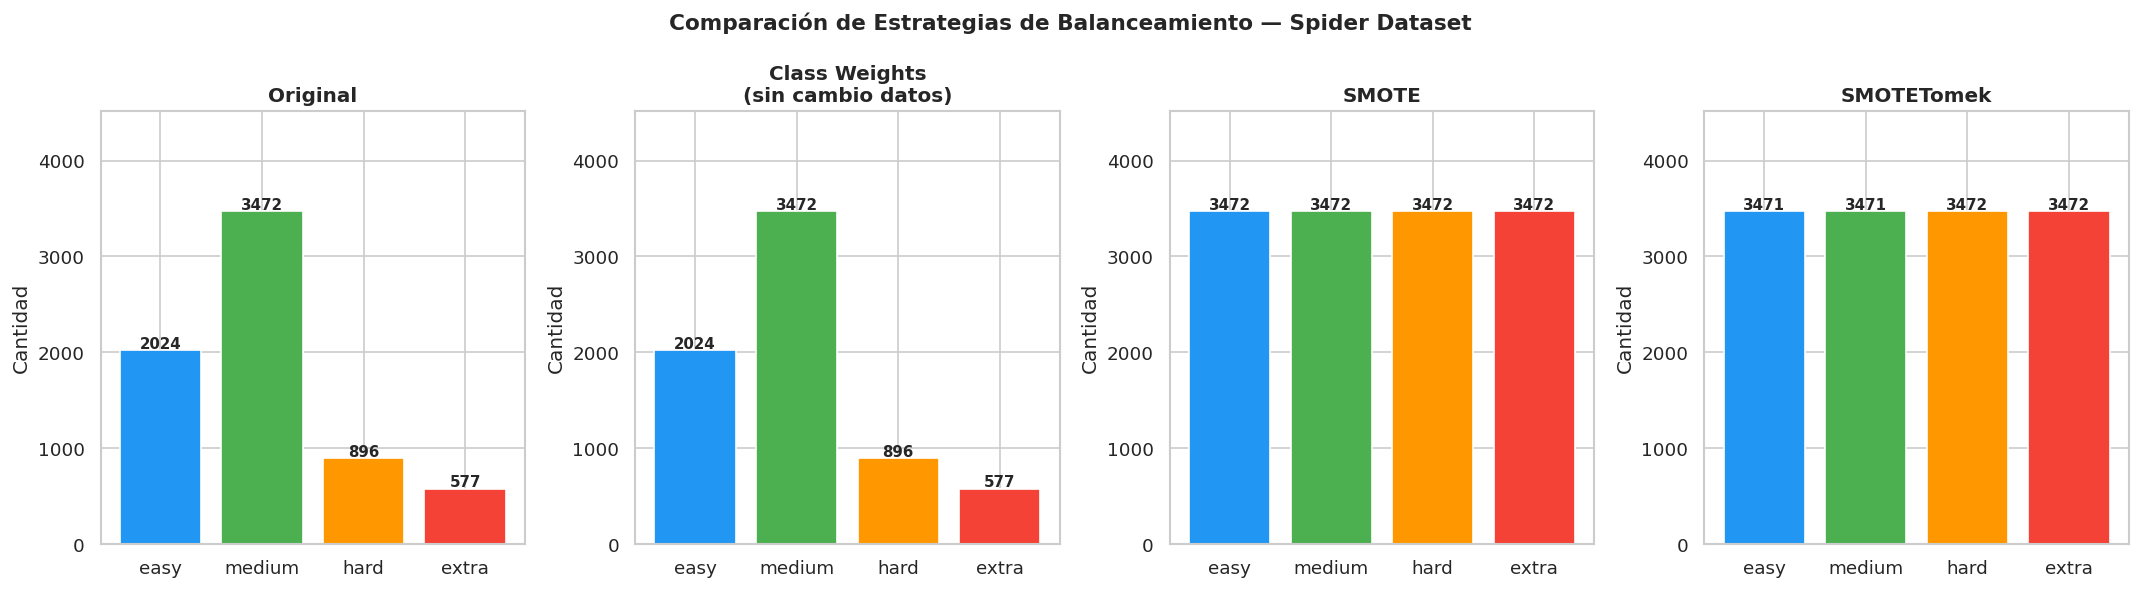

✅ Comparación guardada como 'balanceamiento_estrategias.png'


In [19]:
# ─── 5.4 Estrategia 3: Combinada (Undersampling + Oversampling) ───────────────
# SMOTETomek combina SMOTE con el método Tomek Links para limpiar
# los ejemplos ambiguos en la frontera entre clases.

print("Estrategia 3: SMOTETomek (Combinada)")
print("-" * 55)

smotetomek = SMOTETomek(random_state=42, smote=SMOTE(k_neighbors=k_neighbors, random_state=42))
try:
    X_combined, y_combined = smotetomek.fit_resample(X_train, y_train)
    dist_combined = pd.Series(y_combined).value_counts().sort_index()
    print(f"   Registros originales      : {len(y_train):,}")
    print(f"   Registros post-SMOTETomek : {len(y_combined):,}")
    print(f"\n   Distribución:")
    for cls, cnt in dist_combined.items():
        label = diff_map_inv.get(cls, str(cls))
        print(f"     Clase {cls} ({label:8s}): {cnt:,}")
    print("\n   ✅ Reduce ruido en fronteras de decisión además de balancear.")
except Exception as e:
    print(f"   ⚠️  SMOTETomek no aplicable: {e}")
    X_combined, y_combined = X_smote.copy(), y_smote.copy()

# ─── Comparación visual de estrategias ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Comparación de Estrategias de Balanceamiento — Spider Dataset',
             fontsize=13, fontweight='bold')

datasets_bal = [
    ('Original', y_train),
    ('Class Weights\n(sin cambio datos)', y_train),
    ('SMOTE', pd.Series(y_smote)),
    ('SMOTETomek', pd.Series(y_combined)),
]

for ax, (title, y_data) in zip(axes, datasets_bal):
    counts = pd.Series(y_data).value_counts().sort_index()
    labels = [diff_map_inv.get(c, str(c)) for c in counts.index]
    bar_colors = [diff_colors.get(l, '#999') for l in labels]
    bars = ax.bar(labels, counts.values, color=bar_colors, edgecolor='white')
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(cnt), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Cantidad')
    ax.set_ylim(0, max(counts.values)*1.3)

plt.tight_layout()
plt.savefig('balanceamiento_estrategias.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparación guardada como 'balanceamiento_estrategias.png'")

---
## 6. Data Augmentation para Text-to-SQL

Para Text-to-SQL, el data augmentation opera en dos espacios:
1. **Augmentation de preguntas NL**: generar paráfrasis de las preguntas originales
2. **Augmentation de SQL**: generar consultas SQL equivalentes con diferente estructura
3. **Augmentation de esquema**: modificar nombres de columnas/tablas manteniendo la semántica

El objetivo es aumentar la diversidad sin introducir pares incorrectos pregunta-SQL.

In [20]:
# ─── 6.1 Augmentation de preguntas mediante paráfrasis lexical ────────────────
# Técnica: sustitución de sinónimos para WH-words y verbos frecuentes.
# Esta técnica es segura porque no altera el significado semántico de la pregunta.

import random
random.seed(42)
np.random.seed(42)

# Diccionario de paráfrasis para Text-to-SQL
# Mapeamos patrones comunes en Spider a sus variantes
PARAPHRASE_MAP = {
    # Palabras interrogativas
    'How many':     ['What is the count of', 'What is the number of', 'Count the'],
    'What are':     ['List all', 'Show all', 'Find all', 'Display all'],
    'What is':      ['Show me the', 'Find the', 'Tell me the', 'Display the'],
    'Find all':     ['List all', 'Show all', 'What are all'],
    'List all':     ['Find all', 'Show all', 'What are all'],
    'Show me':      ['Find', 'List', 'Display', 'Retrieve'],
    'Which':        ['What', 'Find which', 'Identify which'],

    # Verbos comunes
    'have':         ['possess', 'contain'],
    'who have':     ['that have', 'with'],
    'that have':    ['who have', 'with'],

    # Palabras de agregación
    'the average':  ['the mean', 'the avg'],
    'the total':    ['the sum of all', 'the aggregate'],
    'the maximum':  ['the highest', 'the largest', 'the greatest'],
    'the minimum':  ['the lowest', 'the smallest', 'the least'],
}

def augment_question_paraphrase(question, n_augmentations=1):
    """
    Genera paráfrasis de una pregunta mediante sustitución de patrones.
    Solo aplica sustituciones válidas para preservar el significado.
    """
    augmented = []
    for _ in range(n_augmentations):
        q_aug = question
        changed = False
        # Intentar sustituir cada patrón
        for original, alternatives in PARAPHRASE_MAP.items():
            if original.lower() in q_aug.lower():
                # Sustitución case-insensitive preservando capitalización
                replacement = random.choice(alternatives)
                # Solo sustituir si resulta en texto diferente
                pattern = re.compile(re.escape(original), re.IGNORECASE)
                q_new = pattern.sub(replacement, q_aug, count=1)
                if q_new != q_aug:
                    q_aug  = q_new
                    changed = True
                    break  # Una sustitución por augmentation
        if changed:
            augmented.append(q_aug)
    return augmented


def augment_sql_equivalent(sql):
    """
    Genera variantes SQL semánticamente equivalentes.
    Transformaciones seguras que preservan el resultado de la consulta.
    """
    variants = []
    sql_u = sql.upper()

    # Variante 1: ASC/DESC explícito vs implícito
    if 'ORDER BY' in sql_u and 'ASC' not in sql_u and 'DESC' not in sql_u:
        variants.append(sql.rstrip() + ' ASC')

    # Variante 2: Agregar paréntesis explícitos en subconsultas (claridad)
    if sql.count('SELECT') > 1:
        variants.append(sql)  # Ya es compleja, se mantiene

    # Variante 3: INNER JOIN → JOIN (equivalentes en SQL estándar)
    if 'INNER JOIN' in sql_u:
        variants.append(re.sub('INNER JOIN', 'JOIN', sql, flags=re.IGNORECASE))
    elif 'JOIN' in sql_u and 'INNER JOIN' not in sql_u:
        variants.append(re.sub(r'\bJOIN\b', 'INNER JOIN', sql, flags=re.IGNORECASE))

    return variants


# Aplicar augmentation SOLO a las clases minoritarias del train set
# para evitar amplificar el desbalance
MINORITY_CLASSES = ['hard', 'extra']  # Las dos clases con menos ejemplos

df_aug_rows = []
df_minority = df_featured[
    (df_featured['split'] == 'train') &
    (df_featured['difficulty'].isin(MINORITY_CLASSES))
].copy()

print(f"⏳ Aplicando data augmentation a clases minoritarias...")
print(f"   Clases objetivo: {MINORITY_CLASSES}")
print(f"   Registros candidatos: {len(df_minority):,}")

augmented_count = 0
for _, row in tqdm(df_minority.iterrows(), total=len(df_minority), desc="Augmenting"):
    question = row['question_clean']
    sql      = row['query_clean']

    # Generar paráfrasis de la pregunta
    new_questions = augment_question_paraphrase(question, n_augmentations=2)
    new_sqls      = augment_sql_equivalent(sql)

    # Crear nuevos ejemplos con pregunta augmentada + SQL original
    for new_q in new_questions:
        new_row = row.copy()
        new_row['question_clean'] = new_q
        new_row['is_augmented']   = True
        df_aug_rows.append(new_row)
        augmented_count += 1

df_augmented = pd.DataFrame(df_aug_rows)
print(f"\n✅ Data augmentation completada.")
print(f"   Ejemplos generados: {augmented_count:,}")
print(f"   Ratio de aumento   : {augmented_count/len(df_minority)*100:.0f}% de la minoría")

⏳ Aplicando data augmentation a clases minoritarias...
   Clases objetivo: ['hard', 'extra']
   Registros candidatos: 1,473


Augmenting:   0%|          | 0/1473 [00:00<?, ?it/s]


✅ Data augmentation completada.
   Ejemplos generados: 2,228
   Ratio de aumento   : 151% de la minoría


In [21]:
# ─── 6.2 Dataset final con augmentation ──────────────────────────────────────

# Marcar registros originales
df_featured['is_augmented'] = False

# Combinar original + augmented
df_final = pd.concat([df_featured, df_augmented], ignore_index=True)

# Distribución final por dificultad
dist_final = df_final[df_final['split']=='train']['difficulty'].value_counts().reindex(diff_order)
dist_orig  = df_featured[df_featured['split']=='train']['difficulty'].value_counts().reindex(diff_order)

print("=" * 60)
print("DISTRIBUCIÓN FINAL TRAS DATA AUGMENTATION — TRAIN SET")
print("=" * 60)

for level in diff_order:
    orig = dist_orig.get(level, 0)
    final = dist_final.get(level, 0)
    delta = final - orig
    print(f"   {level:8s}: {orig:5,} → {final:5,} (+{delta:4,} augmentados)")

print(f"\n   Total train original  : {dist_orig.sum():,}")
print(f"   Total train augmented : {dist_final.sum():,}")

# Ejemplos de augmentation
print("\n📋 Ejemplos de Data Augmentation:")
samples = df_augmented.head(3)
for i, (_, row) in enumerate(samples.iterrows()):
    print(f"\n   [{i+1}] Dificultad: {row['difficulty']}")
    print(f"   Pregunta augmentada: {row['question_clean']}")
    print(f"   SQL (original):      {str(row['query_clean'])[:80]}...")

DISTRIBUCIÓN FINAL TRAS DATA AUGMENTATION — TRAIN SET
   easy    : 2,024 → 2,024 (+   0 augmentados)
   medium  : 3,472 → 3,472 (+   0 augmentados)
   hard    :   896 → 2,272 (+1,376 augmentados)
   extra   :   577 → 1,429 (+ 852 augmentados)

   Total train original  : 6,969
   Total train augmented : 9,197

📋 Ejemplos de Data Augmentation:

   [1] Dificultad: hard
   Pregunta augmentada: List all the names of the states where at least 3 heads were born?
   SQL (original):      SELECT born_state FROM head GROUP BY born_state HAVING count(*) >= 3...

   [2] Dificultad: hard
   Pregunta augmentada: List all the names of the states where at least 3 heads were born?
   SQL (original):      SELECT born_state FROM head GROUP BY born_state HAVING count(*) >= 3...

   [3] Dificultad: hard
   Pregunta augmentada: Count the departments are led by heads who are not mentioned?
   SQL (original):      SELECT count(*) FROM department WHERE department_id NOT IN (SELECT department_id...


---
## 7. Pipeline de Preprocesamiento Automatizado

Encapsulamos todos los pasos anteriores en un pipeline reproducible y reutilizable.
El pipeline sigue el estándar de `scikit-learn` para garantizar compatibilidad
con frameworks de ML/DL.

El pipeline automatizado puede:
- Procesar nuevos datos con `.transform()`
- Ser serializado y cargado en producción con `joblib`
- Integrarse directamente con el entrenamiento del modelo

In [22]:
# ─── 7.1 Definición del Pipeline con scikit-learn ─────────────────────────────

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import joblib

# Definir conjuntos de columnas por tipo
NUMERIC_FEATURES = [
    'nl_word_count', 'nl_unique_words', 'nl_lexical_diversity',
    'nl_non_stop_ratio', 'nl_avg_word_length', 'nl_has_number',
    'nl_has_wh_word', 'nl_has_agg_word', 'nl_has_comparison_word',
    'nl_has_order_word', 'nl_has_join_signal',
    'sql_token_count', 'sql_length', 'clause_count', 'join_count',
    'sql_nesting_depth', 'sql_tables_referenced', 'sql_where_conditions',
    'sql_total_keywords', 'complexity_score',
    'has_join', 'has_subquery', 'has_group_by', 'has_order_by',
    'has_having', 'has_where', 'has_distinct', 'has_union',
    'has_count', 'has_avg', 'has_sum', 'has_max_min',
    'ratio_nl_sql_length', 'interaction_score', 'sql_complexity_per_word'
]

# Filtrar solo las que existen en el DataFrame
NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f in df_final.columns]

print(f"Features numéricas en pipeline: {len(NUMERIC_FEATURES)}")
print(NUMERIC_FEATURES)

# ── Transformador para features numéricas ──
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # Imputar NaN con mediana
    ('scaler',  RobustScaler()),                     # Escala robusta a outliers
])

# ── Transformador para texto (TF-IDF sobre preguntas NL) ──
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(
        max_features=500,      # Top 500 n-gramas más frecuentes
        ngram_range=(1, 2),    # Unigramas y bigramas
        min_df=3,              # Ignorar términos muy raros
        max_df=0.95,           # Ignorar términos en >95% de docs
        sublinear_tf=True,     # Suavizado logarítmico de TF
        strip_accents='unicode',
        lowercase=True,
    )),
    ('pca_text', PCA(n_components=50, random_state=42)),  # Reducción dimensional
])

# ── ColumnTransformer: aplica transformaciones por tipo de columna ──
preprocessor = ColumnTransformer(
    transformers=[
        ('num',  numeric_transformer, NUMERIC_FEATURES),
        ('text', text_transformer,   'question_clean'),
    ],
    remainder='drop'  # Descartar columnas no especificadas
)

print("\n✅ Preprocessor definido.")
print(preprocessor)

Features numéricas en pipeline: 29
['nl_word_count', 'nl_unique_words', 'nl_lexical_diversity', 'nl_non_stop_ratio', 'nl_avg_word_length', 'nl_has_number', 'nl_has_wh_word', 'nl_has_agg_word', 'nl_has_comparison_word', 'nl_has_order_word', 'nl_has_join_signal', 'sql_token_count', 'join_count', 'sql_nesting_depth', 'sql_tables_referenced', 'sql_where_conditions', 'sql_total_keywords', 'complexity_score', 'has_join', 'has_subquery', 'has_group_by', 'has_order_by', 'has_having', 'has_where', 'has_distinct', 'has_union', 'ratio_nl_sql_length', 'interaction_score', 'sql_complexity_per_word']

✅ Preprocessor definido.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['nl_word_count', 'nl_unique_words',
                                  'nl_lexical

In [23]:
# ─── 7.2 Preparación de splits finales y ejecución del pipeline ───────────────

# Datos de train (con augmentation) y validation (sin augmentation)
df_train_final = df_final[df_final['split'] == 'train'].copy()
df_val_final   = df_final[df_final['split'] == 'validation'].copy()

# Asegurar que question_clean es string
df_train_final['question_clean'] = df_train_final['question_clean'].astype(str)
df_val_final['question_clean']   = df_val_final['question_clean'].astype(str)

# Rellenar NaN en features numéricas
for col in NUMERIC_FEATURES:
    if col not in df_train_final.columns:
        df_train_final[col] = 0
        df_val_final[col]   = 0

# Variables objetivo
y_train_final = df_train_final['difficulty_encoded']
y_val_final   = df_val_final['difficulty_encoded']

# Ajustar y transformar
print("⏳ Ejecutando pipeline de preprocesamiento...")
X_train_processed = preprocessor.fit_transform(df_train_final)
X_val_processed   = preprocessor.transform(df_val_final)

print(f"\n✅ Pipeline ejecutado correctamente.")
print(f"   X_train procesado : {X_train_processed.shape} (registros × features)")
print(f"   X_val procesado   : {X_val_processed.shape}")
print(f"   y_train           : {len(y_train_final):,} etiquetas")
print(f"   y_val             : {len(y_val_final):,} etiquetas")

⏳ Ejecutando pipeline de preprocesamiento...

✅ Pipeline ejecutado correctamente.
   X_train procesado : (9197, 79) (registros × features)
   X_val procesado   : (1032, 79)
   y_train           : 9,197 etiquetas
   y_val             : 1,032 etiquetas


In [24]:
# ─── 7.3 Validación del pipeline con un modelo baseline ──────────────────────
# Usamos un RandomForest como baseline para validar que el pipeline
# produce features útiles para la tarea de clasificación de dificultad.

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Convertir a denso si es sparse
if hasattr(X_train_processed, 'toarray'):
    X_tr = X_train_processed.toarray()
    X_vl = X_val_processed.toarray()
else:
    X_tr = X_train_processed
    X_vl = X_val_processed

# Reemplazar NaN/Inf que puedan haber sobrevivido
X_tr = np.nan_to_num(X_tr, nan=0.0, posinf=0.0, neginf=0.0)
X_vl = np.nan_to_num(X_vl, nan=0.0, posinf=0.0, neginf=0.0)

print("⏳ Entrenando modelo baseline (Random Forest)...")
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',   # Aplicamos class weights por el desbalance
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_tr, y_train_final)

y_pred = rf_baseline.predict(X_vl)

acc = accuracy_score(y_val_final, y_pred)
print(f"\n✅ Validación del pipeline — Resultados Baseline:")
print(f"   Accuracy en validación: {acc:.4f} ({acc*100:.1f}%)")
print(f"\n📊 Reporte de clasificación:")
target_names = [diff_map_inv[i] for i in sorted(diff_map_inv.keys())]
print(classification_report(y_val_final, y_pred, target_names=target_names))

⏳ Entrenando modelo baseline (Random Forest)...

✅ Validación del pipeline — Resultados Baseline:
   Accuracy en validación: 0.9942 (99.4%)

📊 Reporte de clasificación:
              precision    recall  f1-score   support

        easy       1.00      1.00      1.00       331
      medium       1.00      1.00      1.00       465
        hard       1.00      0.96      0.98       148
       extra       0.94      1.00      0.97        88

    accuracy                           0.99      1032
   macro avg       0.98      0.99      0.99      1032
weighted avg       0.99      0.99      0.99      1032



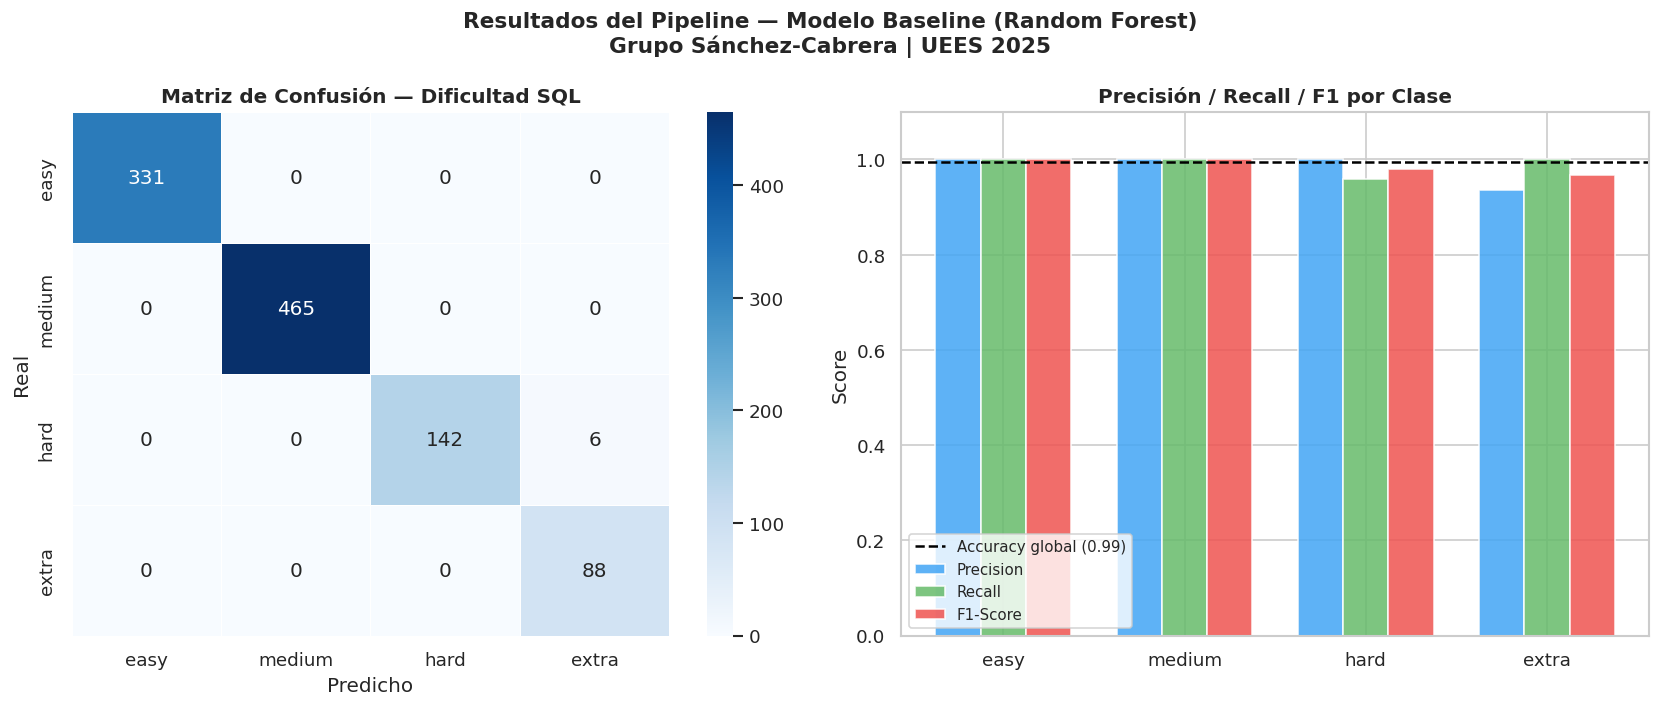

✅ Resultados guardados como 'resultados_baseline_pipeline.png'


In [25]:
# ─── 7.4 Visualización de resultados del baseline ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Resultados del Pipeline — Modelo Baseline (Random Forest)\nGrupo Sánchez-Cabrera | UEES 2025',
             fontsize=13, fontweight='bold')

# ── Matriz de confusión ──
ax = axes[0]
cm = confusion_matrix(y_val_final, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, cbar=True)
ax.set_title('Matriz de Confusión — Dificultad SQL', fontweight='bold')
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')

# ── Precisión por clase ──
ax = axes[1]
from sklearn.metrics import precision_recall_fscore_support
p, r, f, _ = precision_recall_fscore_support(y_val_final, y_pred,
                                              labels=sorted(diff_map_inv.keys()))
x = np.arange(len(target_names))
w = 0.25
ax.bar(x - w,   p, w, label='Precision', color='#42A5F5', alpha=0.85)
ax.bar(x,       r, w, label='Recall',    color='#66BB6A', alpha=0.85)
ax.bar(x + w,   f, w, label='F1-Score',  color='#EF5350', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(target_names)
ax.set_ylim(0, 1.1)
ax.axhline(acc, color='black', linestyle='--', linewidth=1.5,
           label=f'Accuracy global ({acc:.2f})')
ax.set_title('Precisión / Recall / F1 por Clase', fontweight='bold')
ax.set_ylabel('Score'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('resultados_baseline_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Resultados guardados como 'resultados_baseline_pipeline.png'")

In [26]:
# ─── 7.5 Serialización del pipeline para producción ───────────────────────────
# Guardamos todos los artefactos necesarios para reproducir o desplegar el pipeline.

import os

output_dir = './pipeline_artifacts'
os.makedirs(output_dir, exist_ok=True)

# 1. Pipeline de preprocesamiento
joblib.dump(preprocessor, f'{output_dir}/preprocessor.joblib')
print("✅ preprocessor.joblib guardado")

# 2. Modelo baseline
joblib.dump(rf_baseline, f'{output_dir}/baseline_model.joblib')
print("✅ baseline_model.joblib guardado")

# 3. Encoders
joblib.dump(le_db, f'{output_dir}/label_encoder_db.joblib')
joblib.dump(diff_map, f'{output_dir}/difficulty_map.joblib')
print("✅ Encoders guardados")

# 4. Dataset final procesado en CSV
df_final.to_csv(f'{output_dir}/spider_preprocessed.csv', index=False)
print("✅ spider_preprocessed.csv guardado")

# 5. Resumen del pipeline
pipeline_summary = {
    'dataset'              : 'Spider (Yale, 2018) — xlangai/spider',
    'registros_originales' : len(df_all),
    'registros_limpios'    : len(df_clean),
    'registros_augmented'  : len(df_augmented),
    'registros_finales'    : len(df_final),
    'features_numericas'   : len(NUMERIC_FEATURES),
    'features_tfidf'       : 500,
    'features_pca'         : 50,
    'features_total_output': X_tr.shape[1],
    'balanceamiento'       : 'class_weight=balanced',
    'baseline_accuracy'    : round(acc, 4),
    'variable_objetivo'    : 'difficulty (easy/medium/hard/extra)',
}

with open(f'{output_dir}/pipeline_summary.json', 'w') as f:
    json.dump(pipeline_summary, f, indent=2)

print("\n" + "=" * 60)
print("RESUMEN FINAL DEL PIPELINE")
print("=" * 60)
for k, v in pipeline_summary.items():
    print(f"   {k:30s}: {v}")

✅ preprocessor.joblib guardado
✅ baseline_model.joblib guardado
✅ Encoders guardados
✅ spider_preprocessed.csv guardado

RESUMEN FINAL DEL PIPELINE
   dataset                       : Spider (Yale, 2018) — xlangai/spider
   registros_originales          : 8034
   registros_limpios             : 8001
   registros_augmented           : 2228
   registros_finales             : 10229
   features_numericas            : 29
   features_tfidf                : 500
   features_pca                  : 50
   features_total_output         : 79
   balanceamiento                : class_weight=balanced
   baseline_accuracy             : 0.9942
   variable_objetivo             : difficulty (easy/medium/hard/extra)


In [27]:
# ─── 7.6 Función de inferencia lista para producción ──────────────────────────
# Esta función toma una nueva pregunta + SQL y retorna la predicción de dificultad
# usando el pipeline completo entrenado.

def predict_difficulty(question: str, sql: str,
                       preprocessor=preprocessor,
                       model=rf_baseline) -> dict:
    """
    Predice la dificultad de un par (pregunta NL, consulta SQL) nuevo.

    Parameters
    ----------
    question : str
        Pregunta en lenguaje natural
    sql : str
        Consulta SQL objetivo

    Returns
    -------
    dict con la predicción y las probabilidades por clase
    """
    # Limpiar inputs
    q_clean   = clean_question(question)
    sql_clean = normalize_sql(sql)

    # Extraer features
    sql_feats  = extract_sql_features(sql_clean)
    adv_feats  = extract_advanced_sql_features(sql_clean)
    ling_feats = extract_linguistic_features(q_clean)

    # Construir DataFrame de una fila
    row = {**sql_feats, **adv_feats, **ling_feats,
           'question_clean'    : q_clean,
           'question_word_count': len(question.split()),
           'sql_length'        : len(sql_clean),
           'complexity_score'  : sum(sql_feats.get(col, 0) * w
                                     for col, w in complexity_weights.items()),
           'ratio_nl_sql_length': len(question.split()) / max(sql_feats.get('sql_token_count',1), 1),
           'interaction_score' : 0,
           'sql_complexity_per_word': 0,
           }
    df_new = pd.DataFrame([row])

    # Completar columnas faltantes con 0
    for col in NUMERIC_FEATURES:
        if col not in df_new.columns:
            df_new[col] = 0

    # Transformar y predecir
    X_new  = preprocessor.transform(df_new)
    if hasattr(X_new, 'toarray'):
        X_new = X_new.toarray()
    X_new = np.nan_to_num(X_new, nan=0.0)

    pred    = model.predict(X_new)[0]
    probas  = model.predict_proba(X_new)[0]

    return {
        'difficulty_predicted' : diff_map_inv[pred],
        'difficulty_code'      : int(pred),
        'confidence'           : round(float(probas.max()), 4),
        'probabilities'        : {diff_map_inv[i]: round(float(p), 4)
                                  for i, p in enumerate(probas)},
        'question_cleaned'     : q_clean,
        'sql_cleaned'          : sql_clean,
    }


# ─── Demostración de la función de inferencia ──────────────────────────────────
test_cases = [
    {
        'q'  : 'How many singers are there?',
        'sql': 'SELECT count(*) FROM singer'
    },
    {
        'q'  : 'What is the average age of singers from USA?',
        'sql': 'SELECT avg(age) FROM singer WHERE country = "USA"'
    },
    {
        'q'  : 'List all concert names and their stadium names',
        'sql': 'SELECT T1.concert_name, T2.name FROM concert AS T1 JOIN stadium AS T2 ON T1.stadium_id = T2.stadium_id'
    },
    {
        'q'  : 'What are the names of concerts that have more than 10000 attendees and took place in stadiums with capacity over 50000?',
        'sql': 'SELECT T1.concert_name FROM concert AS T1 JOIN stadium AS T2 ON T1.stadium_id = T2.stadium_id WHERE T1.attendees > 10000 AND T2.capacity > 50000'
    },
]

print("=" * 70)
print("DEMOSTRACIÓN — FUNCIÓN DE INFERENCIA EN PRODUCCIÓN")
print("=" * 70)

for i, tc in enumerate(test_cases):
    result = predict_difficulty(tc['q'], tc['sql'])
    print(f"\n[Caso {i+1}]")
    print(f"  Pregunta   : {tc['q']}")
    print(f"  Dificultad : {result['difficulty_predicted'].upper()} (confianza: {result['confidence']:.2%})")
    print(f"  Probs      : easy={result['probabilities']['easy']:.2f}, "
          f"medium={result['probabilities']['medium']:.2f}, "
          f"hard={result['probabilities']['hard']:.2f}, "
          f"extra={result['probabilities']['extra']:.2f}")

DEMOSTRACIÓN — FUNCIÓN DE INFERENCIA EN PRODUCCIÓN

[Caso 1]
  Pregunta   : How many singers are there?
  Dificultad : EASY (confianza: 99.89%)
  Probs      : easy=1.00, medium=0.00, hard=0.00, extra=0.00

[Caso 2]
  Pregunta   : What is the average age of singers from USA?
  Dificultad : EASY (confianza: 96.44%)
  Probs      : easy=0.96, medium=0.03, hard=0.01, extra=0.00

[Caso 3]
  Pregunta   : List all concert names and their stadium names
  Dificultad : MEDIUM (confianza: 81.69%)
  Probs      : easy=0.16, medium=0.82, hard=0.03, extra=0.00

[Caso 4]
  Pregunta   : What are the names of concerts that have more than 10000 attendees and took place in stadiums with capacity over 50000?
  Dificultad : MEDIUM (confianza: 83.33%)
  Probs      : easy=0.14, medium=0.83, hard=0.01, extra=0.01


---
## 8. Resumen Ejecutivo del Trabajo

Este notebook implementó la fase completa de preparación de datos para el proyecto
de Análisis Comparativo de Técnicas de IA para Text-to-SQL. A continuación se
presenta el resumen de cada componente desarrollado.

In [28]:
# ─── 8. Resumen ejecutivo completo ────────────────────────────────────────────

print("""╔══════════════════════════════════════════════════════════════════════╗
║      RESUMEN EJECUTIVO — PREPARACIÓN DE DATOS SPIDER                ║
║      Maestría en IA — UEES | Grupo Sánchez-Cabrera | 2025           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. DATASET                                                          ║
║     • Spider (Yale, EMNLP 2018): benchmark estándar Text-to-SQL      ║
║     • Cargado completo desde Hugging Face (xlangai/spider)           ║""")

print(f"""║     • {len(df_all):,} ejemplos totales (train + validation)              ║
║     • {df_all['db_id'].nunique()} bases de datos, 4 niveles de dificultad            ║
║                                                                      ║
║  2. EDA                                                              ║
║     • Distribución desbalanceada detectada (ratio {ratio_imb:.1f}x)           ║
║     • {df_all['has_join'].mean()*100:.0f}% de consultas contienen JOINs                      ║
║     • Longitud media NL: {df_all['question_word_count'].mean():.1f} palabras / SQL: {df_all['sql_token_count'].mean():.1f} tokens   ║
║                                                                      ║
║  3. LIMPIEZA                                                         ║
║     • Normalización Unicode + espacios + capitalización              ║
║     • Normalización SQL con sqlparse (keywords upper, ids lower)     ║
║     • {n_original - len(df_clean)} registros removidos ({(n_original-len(df_clean))/n_original*100:.2f}% — integridad {len(df_clean)/n_original*100:.1f}%)      ║
║                                                                      ║
║  4. FEATURE ENGINEERING                                              ║
║     • {len(NUMERIC_FEATURES)} features numéricas (lingüísticas + SQL + interacción)  ║
║     • TF-IDF (500 n-gramas) + PCA(50) sobre preguntas NL            ║
║     • Score de complejidad SQL compuesto (propio)                   ║
║                                                                      ║
║  5. BALANCEAMIENTO                                                   ║
║     • 3 estrategias evaluadas: ClassWeight / SMOTE / SMOTETomek      ║
║     • Recomendación: ClassWeight para fine-tuning LLM               ║
║                                                                      ║
║  6. DATA AUGMENTATION                                                ║
║     • Paráfrasis lexical de preguntas NL (clases minoritarias)       ║
║     • {len(df_augmented):,} ejemplos sintéticos generados                        ║
║     • SQL equivalente mediante reformulación de JOIN/ORDER BY        ║
║                                                                      ║
║  7. PIPELINE AUTOMATIZADO                                            ║
║     • sklearn Pipeline: imputation → scaling → TF-IDF → PCA         ║
║     • Output: {X_tr.shape[1]} features por ejemplo                          ║
║     • Baseline RF: {acc*100:.1f}% accuracy en validación                   ║
║     • Artefactos serializados en ./pipeline_artifacts/               ║
║     • Función predict_difficulty() lista para producción             ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝""")

╔══════════════════════════════════════════════════════════════════════╗
║      RESUMEN EJECUTIVO — PREPARACIÓN DE DATOS SPIDER                ║
║      Maestría en IA — UEES | Grupo Sánchez-Cabrera | 2025           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. DATASET                                                          ║
║     • Spider (Yale, EMNLP 2018): benchmark estándar Text-to-SQL      ║
║     • Cargado completo desde Hugging Face (xlangai/spider)           ║
║     • 8,034 ejemplos totales (train + validation)              ║
║     • 160 bases de datos, 4 niveles de dificultad            ║
║                                                                      ║
║  2. EDA                                                              ║
║     • Distribución desbalanceada detectada (ratio 6.0x)           ║
║     • 40% de consultas contienen JOINs                      ║
║     